In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np

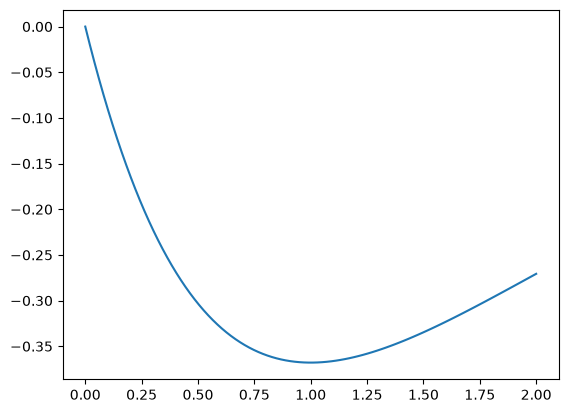

In [4]:
def f_base(x):
    ans = -x / math.pow(math.e, x)
    return ans

# graph
xs = np.linspace(0, 2, 100)
ys = np.array(list(map(f_base, xs)))

plt.plot(xs, ys)
plt.show()

In [5]:
# Метод поразрядного поиска
def method_1(a, b, eps):
    iter_c = 0
    f_call_c = 0


    h = (b - a) / 4

    def f(x):
        nonlocal f_call_c
        f_call_c += 1
        return f_base(x)

    x0 = a
    f_x0 = f(x0)

    while abs(h) > eps:
        iter_c += 1

        x1 = x0 + h
        f_x1 = f(x1)

        if f_x0 > f_x1:
            x0 = x1
            f_x0 = f_x1
            if(a < x0 < b):
                continue            

        x0 = x1
        f_x0 = f_x1
        h = -h/4
    
    return (x0, f_x0, iter_c, f_call_c)

In [6]:
# Метод деления отрезка пополам
def method_2(a, b, eps):
    iter_c = 0
    f_call_c = 0

    def f(x):
        nonlocal f_call_c
        f_call_c += 1
        return f_base(x)

    xm = (a+b)/2
    f_xm = f(xm)
    l = b - a
    
    while l > eps:
        iter_c += 1
        x1 = a + l/4
        x2 = b - l/4

        f_x1 = f(x1)
        if f_x1 < f_xm:
            b = xm
            xm = x1
            f_xm = f_x1


        else:
            f_x2 = f(x2)
            if f_x2 < f_xm:
                a = xm
                xm = x2
                f_xm = f_x2
            else: 
                a = x1
                b = x2

        l = b - a
    return (xm, f_xm, iter_c, f_call_c)

In [ ]:
# метод парабол
def method_3(a, b, eps):
    iter_c = 0
    f_call_c = 0

    def f(x):
        nonlocal f_call_c
        f_call_c += 1
        return f_base(x)
    
    f_a = f(a)
    f_b = f(b)
    c = a + (3 - math.sqrt(5)) / 2 * (b - a)
    f_c = f(c)


    while max(c - a, b - c) > 2 * eps:
        iter_c += 1
        p = math.pow(b - c, 2) * (f_a - f_c) - math.pow(c - a, 2) * (f_b - f_c)
        q = 2 * ((b - c)*(f_a - f_c) + (c - a)*(f_b - f_c))

        if q != 0 and (c + p/q) != c:
            t = c + p/q
        else:
            t = (a + c) / 2
        f_t = f(t)

        
        if t < c:
            if f_t < f_c:
                b = c
                f_b = f_c
                c = t
                f_c = f_t
            else: 
                a = t
                f_a = f_t
        else:
            if f_t < f_c:
                a = c
                f_a = f_c
                c = t
                f_c = f_t
            else: 
                b = t
                f_b = f_t

    return (c, f_c, iter_c, f_call_c)

In [13]:
a = 0
b = 2
eps = 0.0001

(xm_1, f_xm_1, iter_c_1, f_call_c_1) = method_1(a, b, eps)
print(iter_c_1, f_call_c_1, xm_1, f_xm_1)

(xm_2, f_xm_2, iter_c_2, f_call_c_2) = method_2(a, b, eps)
print(iter_c_2, f_call_c_2, xm_2, f_xm_2)

(xm_3, f_xm_3, iter_c_3, f_call_c_3) = method_3(a, b, eps)
print(iter_c_3, f_call_c_3, xm_3, f_xm_3)

33 34 1.0001220703125 -0.36787943843074994
15 31 1.0 -0.36787944117144233
16 19 1.000000012102252 -0.36787944117144233


In [15]:
a = 0
b = 3
eps = 0.0001

(xm_1, f_xm_1, iter_c_1, f_call_c_1) = method_1(a, b, eps)
print(iter_c_1, f_call_c_1, xm_1, f_xm_1)

(xm_2, f_xm_2, iter_c_2, f_call_c_2) = method_2(a, b, eps)
print(iter_c_2, f_call_c_2, xm_2, f_xm_2)

(xm_3, f_xm_3, iter_c_3, f_call_c_3) = method_3(a, b, eps)
print(iter_c_3, f_call_c_3, xm_3, f_xm_3)

32 33 1.0001220703125 -0.36787943843074994
15 23 0.9999847412109375 -0.36787944112861515
39 42 1.000000016668944 -0.3678794411714423
